In [1]:
import numpy as np
import pandas as pd

# Création d'un dataset réaliste : Comportement clients e-commerce
np.random.seed(42)
n_clients = 500

# Génération de données corrélées de manière réaliste
age = np.random.normal(35, 12, n_clients)
age = np.clip(age, 18, 70)  # Limiter l'âge entre 18 et 70

# Le revenu augmente généralement avec l'âge (corrélation positive modérée)
revenu = 25000 + (age - 18) * 800 + np.random.normal(0, 8000, n_clients)
revenu = np.clip(revenu, 20000, 120000)

# Le temps passé sur le site dépend de l'âge (les plus jeunes passent plus de temps)
temps_site = 45 - (age - 35) * 0.5 + np.random.normal(0, 10, n_clients)
temps_site = np.clip(temps_site, 5, 120)

# Le montant des achats dépend du revenu (corrélation forte positive)
montant_achats = revenu * 0.015 + np.random.normal(0, 150, n_clients)
montant_achats = np.clip(montant_achats, 50, 2500)

# Le nombre de visites est corrélé au temps passé
nb_visites = temps_site * 0.3 + np.random.normal(0, 3, n_clients)
nb_visites = np.clip(nb_visites, 1, 50)

# Le taux de conversion dépend du temps passé et du montant
taux_conversion = 0.05 + (temps_site / 1000) + (montant_achats / 50000) + np.random.normal(0, 0.02, n_clients)
taux_conversion = np.clip(taux_conversion, 0, 0.3)

# Score de satisfaction (légèrement corrélé au montant et au temps)
satisfaction = 3.5 + (montant_achats / 1000) * 0.3 + (temps_site / 100) * 0.2 + np.random.normal(0, 0.5, n_clients)
satisfaction = np.clip(satisfaction, 1, 5)

# Création du DataFrame
df_clients = pd.DataFrame({
    'age': age.round(0),
    'revenu_annuel': revenu.round(0),
    'temps_site_min': temps_site.round(1),
    'montant_achats_euros': montant_achats.round(2),
    'nb_visites_mois': nb_visites.round(0),
    'taux_conversion': taux_conversion.round(3),
    'score_satisfaction': satisfaction.round(1)
})

df_clients.head(10)

,age,revenu_annuel,temps_site_min,montant_achats_euros,nb_visites_mois,taux_conversion,score_satisfaction
0,41.0,50778.0,56.0,878.42,15.0,0.135,2.9
1,33.0,52548.0,55.1,705.54,16.0,0.139,3.4
2,43.0,33629.0,41.7,381.71,10.0,0.093,3.5
3,53.0,57725.0,29.4,865.37,8.0,0.084,4.8
4,32.0,31147.0,53.4,441.68,10.0,0.091,4.0
5,32.0,32455.0,50.3,418.85,16.0,0.092,3.1
6,54.0,49021.0,44.5,839.78,13.0,0.170,4.1
7,44.0,39055.0,46.7,729.13,12.0,0.136,3.0
8,29.0,34481.0,58.3,530.48,19.0,0.092,4.3
9,42.0,37161.0,36.4,779.04,14.0,0.076,3.6


## Calcul des corrélations

**Exemple 1** : Corrélation entre revenu et le montant des achats. On s'attend à une corrélation positive forte. 

In [2]:
corr_revenu_achats = df_clients["revenu_annuel"].corr(df_clients["montant_achats_euros"])

print(f"Coefficient : {corr_revenu_achats:.03f}")

print("Interprétation")

if abs(corr_revenu_achats) >= 0.7:
    print("Corrélation forte")
elif abs(corr_revenu_achats) >= 0.3:
    print("Corrélation modérée")
else:
    print("Corrélation faible")

if corr_revenu_achats > 0:
    print("Relation positive : Quand le revenu augmente, les achats augmentent")
else:
    print("Relation négative : Quand le revenu augmente, les achats diminuent")

Coefficient : 0.756
Interprétation
Corrélation forte
Relation positive : Quand le revenu augmente, les achats augmentent


## Visualisation de cette corrélation

[ 0.01528495 -5.36427272]
 
0.01528 x - 5.364


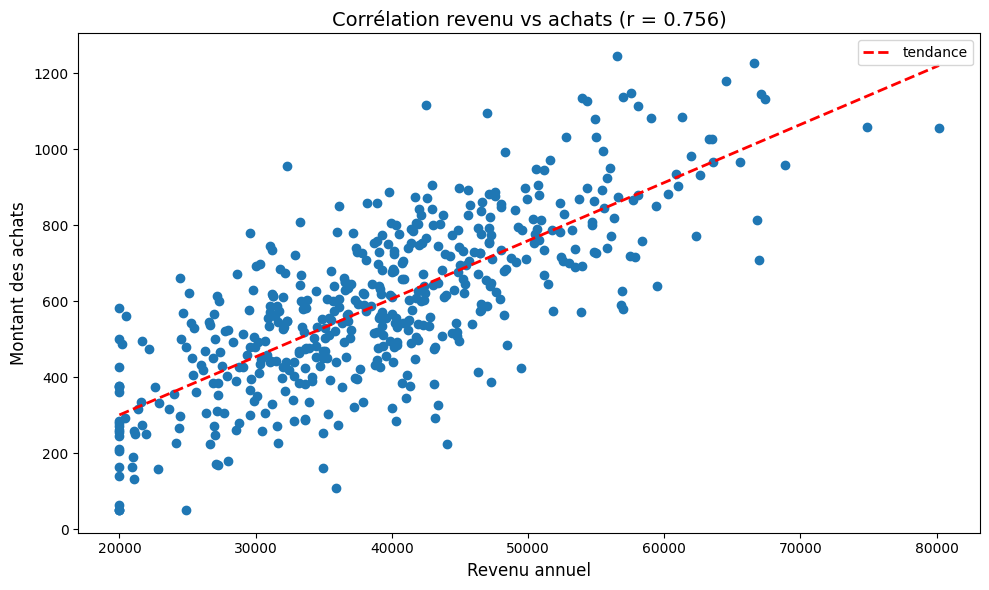

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df_clients["revenu_annuel"], df_clients["montant_achats_euros"])
plt.xlabel("Revenu annuel", fontsize=12)
plt.ylabel("Montant des achats", fontsize=12)
plt.title(f"Corrélation revenu vs achats (r = {corr_revenu_achats:.03f})", fontsize=14)

"""
Ajout d'une ligne de tendance :

np.polyfit(x, y, degré) : Calcul les coefficients d'un polynôme qui s'ajuste au mieux aux données.

x : revenu_annuel
y : montant_achats_euros
1 : degré du polynôme (1= droite, 2 = parabole, ect...)

Résultat : z contient deux valeurs [a,b] représentant l'équation de la droite
"""
z = np.polyfit(df_clients["revenu_annuel"], df_clients["montant_achats_euros"], 1)
print(z)
# transforme les coefficients z en une fonction utilisable
p = np.poly1d(z)

print(p)

plt.plot(df_clients["revenu_annuel"].sort_values(), p(df_clients["revenu_annuel"].sort_values()), "r--", linewidth=2, label="tendance")
plt.legend()
plt.tight_layout()
plt.show()

## Matrice de corrélation complète

- La **matrice de corrélation** montre les corrélations entre toutes les paires de variables

In [4]:
matrice_corr = df_clients.corr()

matrice_corr.round(3)

,age,revenu_annuel,temps_site_min,montant_achats_euros,nb_visites_mois,taux_conversion,score_satisfaction
age,1.000,0.734,-0.519,0.581,-0.409,-0.116,0.076
revenu_annuel,0.734,1.000,-0.340,0.756,-0.260,0.038,0.115
temps_site_min,-0.519,-0.340,1.000,-0.281,0.764,0.444,-0.060
montant_achats_euros,0.581,0.756,-0.281,1.000,-0.251,0.112,0.130
nb_visites_mois,-0.409,-0.260,0.764,-0.251,1.000,0.320,-0.027
taux_conversion,-0.116,0.038,0.444,0.112,0.320,1.000,-0.051
score_satisfaction,0.076,0.115,-0.060,0.130,-0.027,-0.051,1.000


## Visualisation des corrélations

**HEATMAP** (carte de chaleur)

- La heatmap est la visualisation de référence pour la matrice de corrélation
- Comment lire cette heatmap :
    - **Rouge intense** : Corrélation positive forte (+0.7 à +1)
    - **Blanc** : pas de corrélation (proche de 0)
    - **Bleu intense**: Corrélation négative forte (-0.7 à -1)
    - La diagonal est toujours à 1 (une variable corrèle parfaitement avec elle-même)

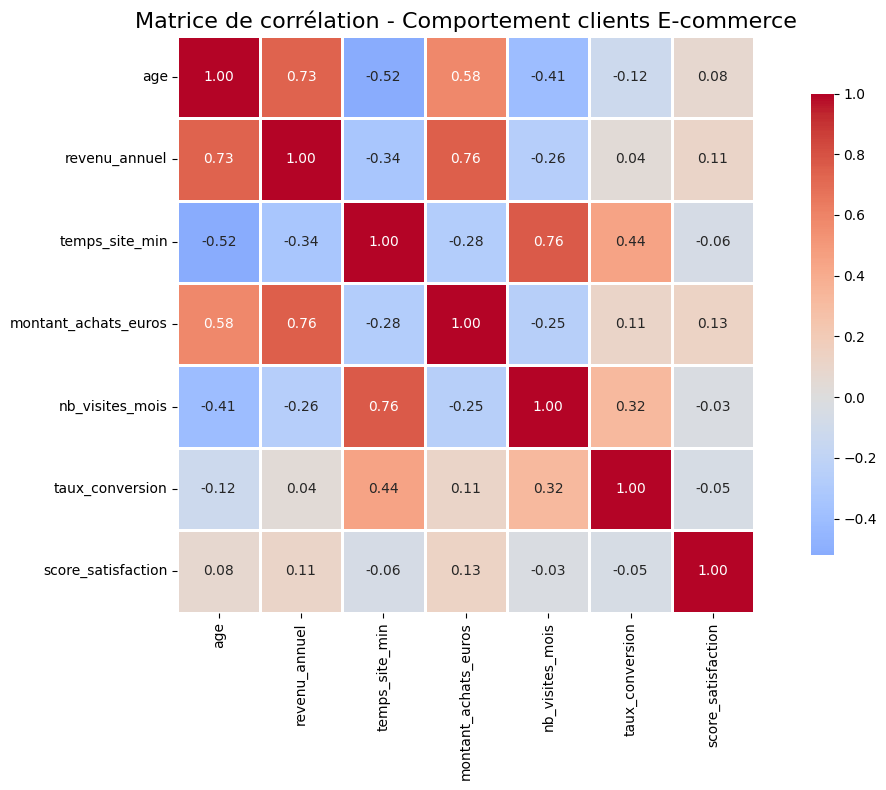

In [5]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(matrice_corr,
            annot=True, # Afficher les valeurs
            cmap="coolwarm",
            center=0, # Centrer la palette sur 0
            square=True, # cases carrées
            linewidths=1, # lignes de séparation
            cbar_kws={"shrink" : 0.8}, # barre de couleur
            fmt=".2f" # Format des nombres

)

plt.title("Matrice de corrélation - Comportement clients E-commerce", fontsize=16)
plt.tight_layout()
plt.show()

## Pairplot : Visualisation des toutes les relations

- Comment lire le pairplot:
    - Chaque cellule montre la relation entre deux variables
    - La diagonale montre la distribution de chaque variable
    - Cherchez les patterns linéaire (corrélations forte)
    - Un nuage de point dispersé = faible corrélation

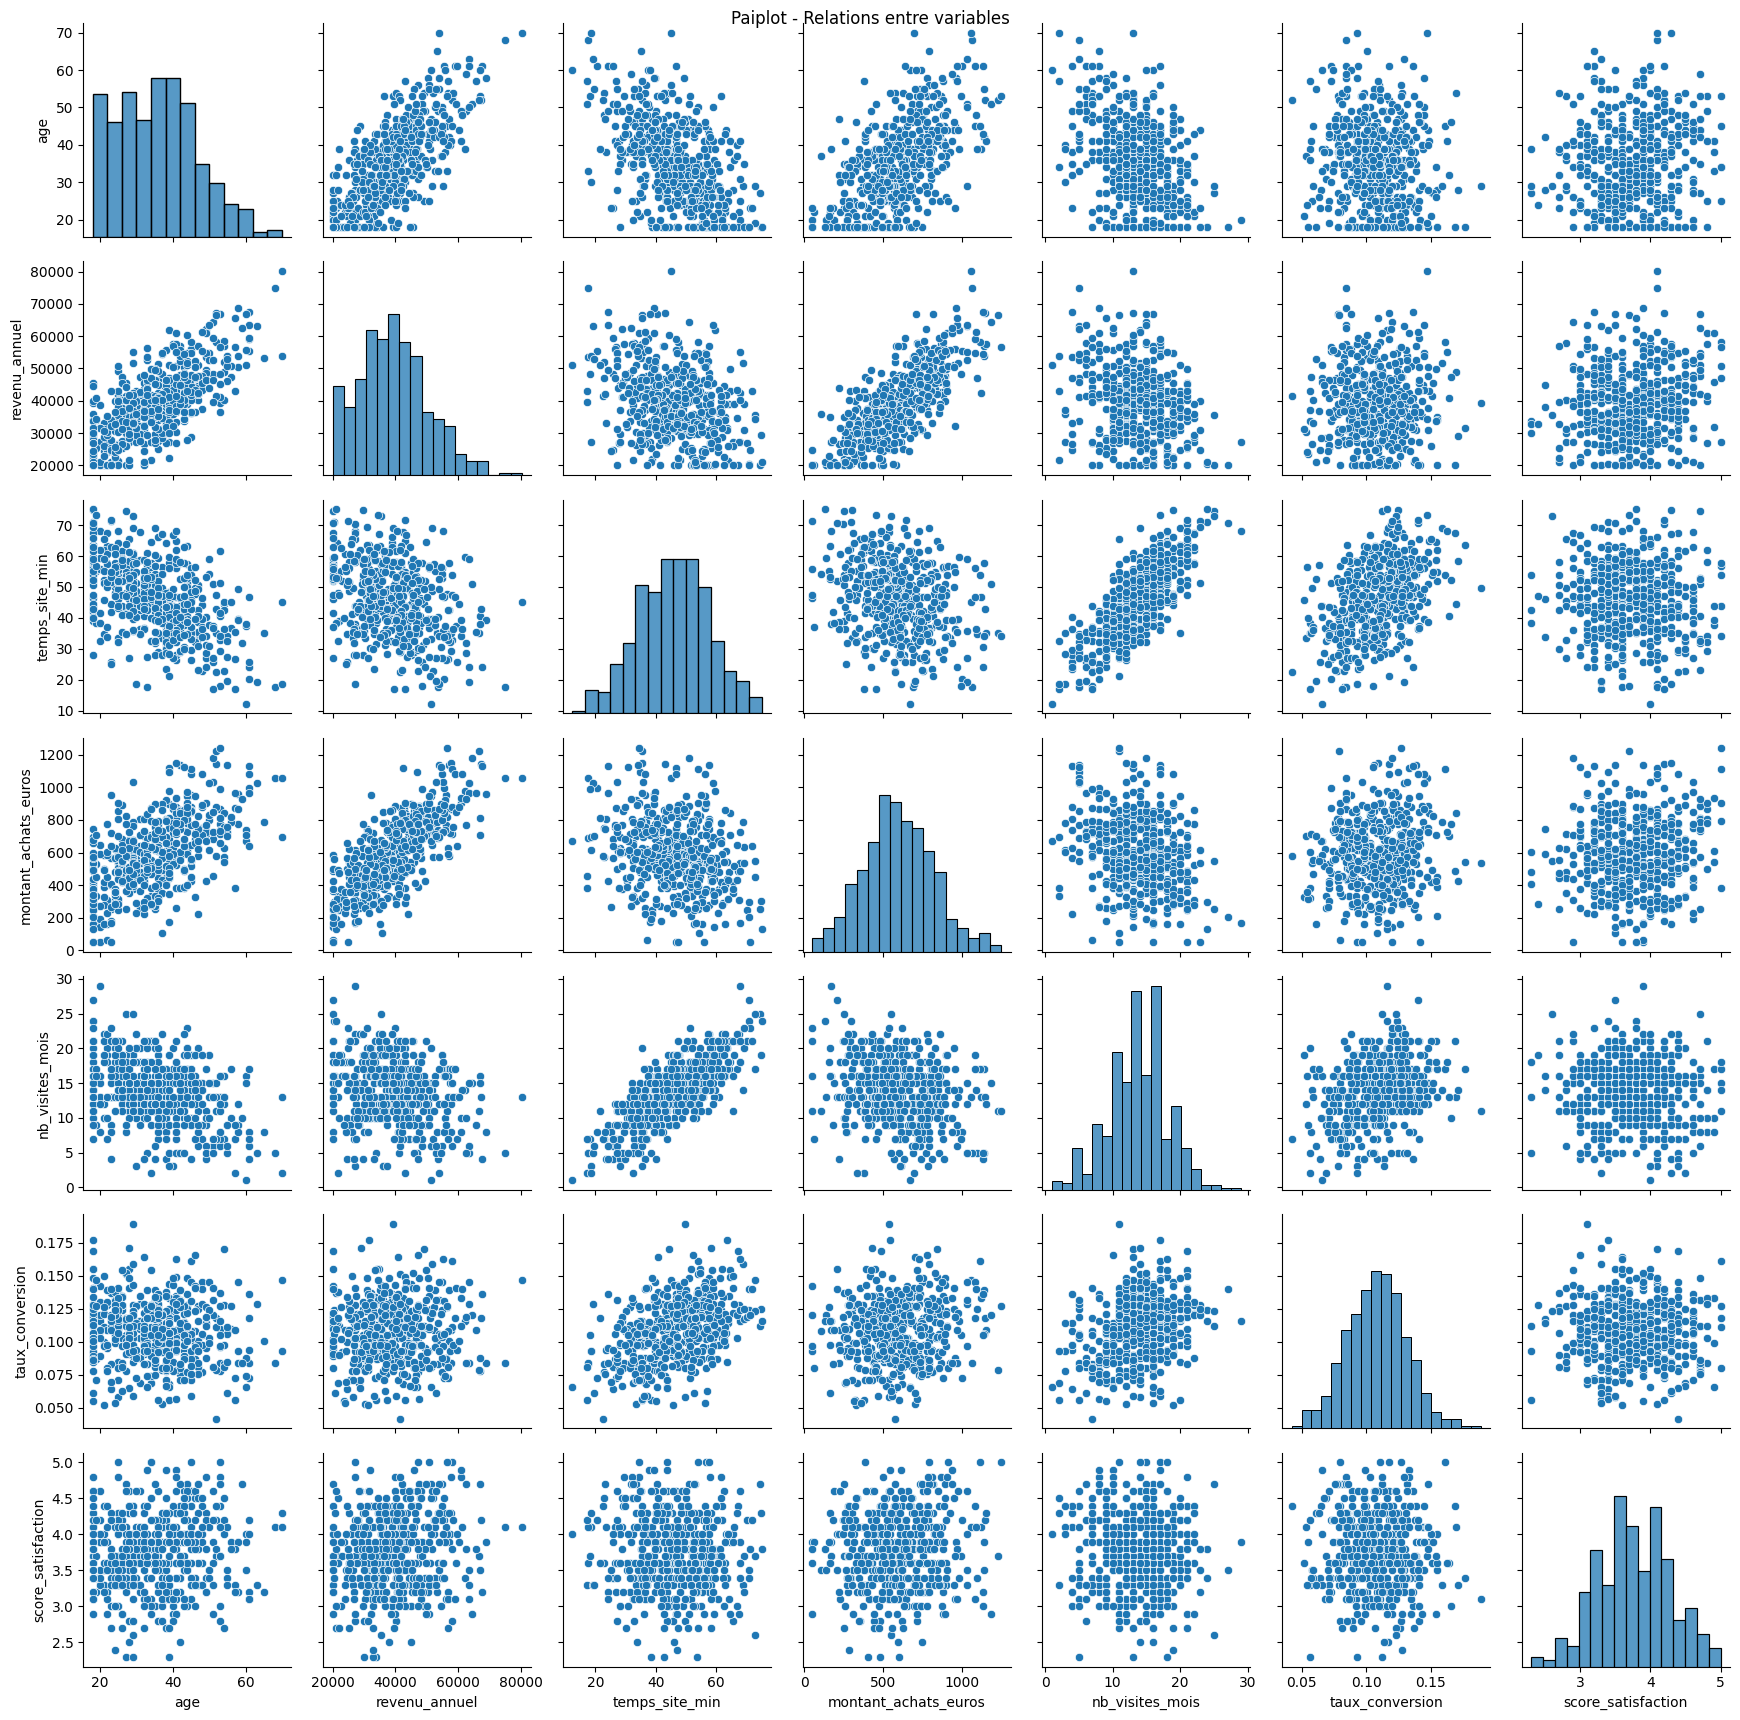

In [6]:
sns.pairplot(df_clients)

plt.suptitle("Paiplot - Relations entre variables")
plt.tight_layout()
plt.show()

## Identification des corrélations importantes

In [7]:
def trouver_correlations_fortes(matrice_corr, seuil=0.5):
    """
    Trouve les paires de variables avec une corrélation absolue > seuil
    Exclut la diagonale
    """

    correlations = []

    # parcourir la matrice triangulaire supérieur (éviter les doublons)
    # i => parcours les lignes
    # j => parcours les colonnes
    for i in range(len(matrice_corr.columns)):
        for j in range(i+1, len(matrice_corr.columns)):
            var1 = matrice_corr.columns[i]
            var2 = matrice_corr.columns[j]
            corr_value = matrice_corr.iloc[i, j]

            if abs(corr_value) >= seuil:
                correlations.append({
                    'Variable 1' : var1,
                    'Variable 2': var2,
                    "Corrélation" : corr_value,
                    "Force": 'Forte' if abs(corr_value) >= 0.7 else "Modérée"
                })
    
    df_corr = pd.DataFrame(correlations)

    return df_corr

# Recherche des corrélation fortes (|r| >= 0.7)
corr_importantes = trouver_correlations_fortes(matrice_corr, seuil=0.7)

corr_importantes

,Variable 1,Variable 2,Corrélation,Force
0,age,revenu_annuel,0.733591,Forte
1,revenu_annuel,montant_achats_euros,0.756222,Forte
2,temps_site_min,nb_visites_mois,0.763782,Forte


## Test de significativité

- Vérifie si la corrélation est due au hasard ou non
- **Exemple** : Corrélation revenu vs montants achats
- Interprétation :
    - si `p_value` < 0.05 : Il y a moins de 5% de chance que cette corrélation soit due au hasard
    - si `p_value` > 0.05 : Cette corrélation pourrait être due au hasard

In [8]:
# pip install scipy
from scipy.stats import pearsonr

corr_value, p_value = pearsonr(df_clients["revenu_annuel"], df_clients["montant_achats_euros"])

print(f"Coefficient de corrélation : {corr_value:.3f}")
print(f"P-value : {p_value:.3f}")

if p_value < 0.05:
    print("La corrélation est statistiquement SIGNIFICATIF")
else:
    print("La corrélation n'est pas statistiquement significative")

Coefficient de corrélation : 0.756
P-value : 0.000
La corrélation est statistiquement SIGNIFICATIF


## EXERCICE 1 : Analyse de Corrélations

**Objectif** : Analyser les corrélations dans un nouveau dataset

**Consignes** :

1. Chargez le dataset fourni ci-dessous (données de ventes retail)
2. Calculez la matrice de corrélation
3. Créez une heatmap
4. Identifiez les 3 corrélations les plus fortes
5. Créez un scatter plot pour la corrélation la plus forte

In [9]:
np.random.seed(123)
n_produits = 400

prix = np.random.uniform(10, 200, n_produits)
quantite_vendue = 500 - prix * 1.5 + np.random.normal(0, 50, n_produits)
quantite_vendue = np.clip(quantite_vendue, 10, 800)

budget_marketing = prix * 0.15 + np.random.normal(0, 5, n_produits)
note_client = 3 + (quantite_vendue / 300) + np.random.normal(0, 0.5, n_produits)
note_client = np.clip(note_client, 1, 5)

taux_retour = 0.15 - (note_client / 50) + np.random.normal(0, 0.03, n_produits)
taux_retour = np.clip(taux_retour, 0, 0.4)

df_retail = pd.DataFrame({
    'prix_unitaire': prix.round(2),
    'quantite_vendue': quantite_vendue.round(0),
    'budget_marketing': budget_marketing.round(2),
    'note_client': note_client.round(1),
    'taux_retour': taux_retour.round(3)
})

print(f"Dimensions : {df_retail.shape}")
df_retail.head()

Dimensions : (400, 5)


,prix_unitaire,quantite_vendue,budget_marketing,note_client,taux_retour
0,142.33,199.0,23.31,3.6,0.087
1,64.37,386.0,13.39,4.6,0.000
2,53.10,411.0,9.33,4.2,0.015
3,114.75,350.0,19.34,4.2,0.046
4,146.70,273.0,20.85,3.8,0.102


In [10]:
matrice_corr_retail = df_retail.corr()

# Affichage de la matrice avec 3 décimales
print("Matrice de corrélation :")
matrice_corr_retail.round(3)

Matrice de corrélation :


,prix_unitaire,quantite_vendue,budget_marketing,note_client,taux_retour
prix_unitaire,1.000,-0.843,0.840,-0.539,0.161
quantite_vendue,-0.843,1.000,-0.688,0.609,-0.156
budget_marketing,0.840,-0.688,1.000,-0.441,0.133
note_client,-0.539,0.609,-0.441,1.000,-0.307
taux_retour,0.161,-0.156,0.133,-0.307,1.000


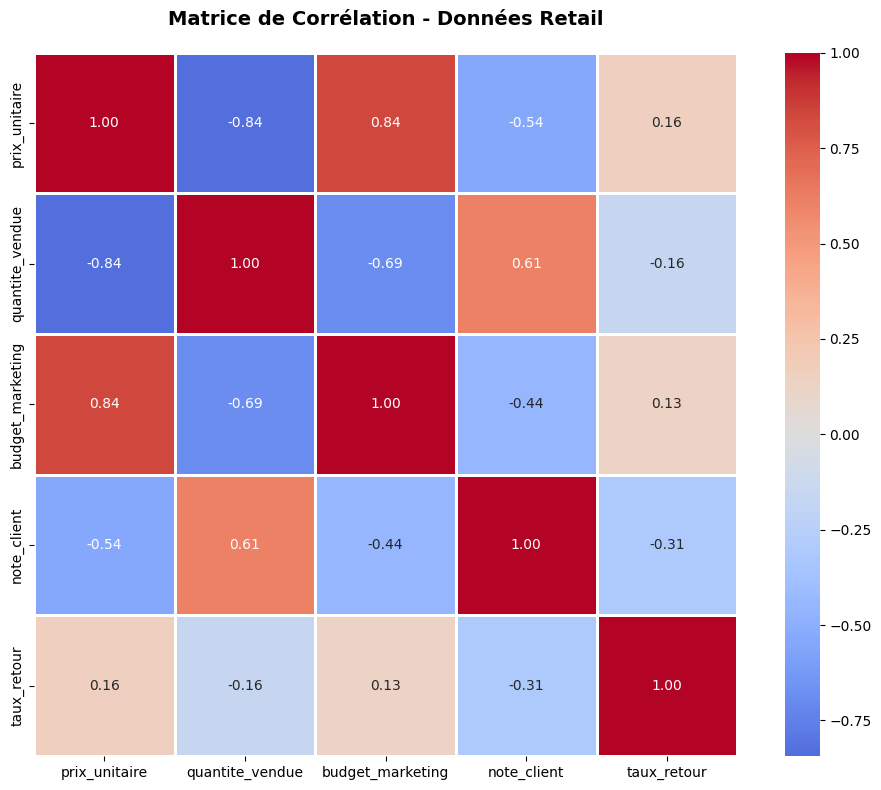

In [11]:
plt.figure(figsize=(10, 8))

sns.heatmap(matrice_corr_retail,
            annot=True,  # Afficher les valeurs
            cmap="coolwarm",  # Palette de couleurs
            center=0,  # Centrer sur 0
            square=True,  # Cases carrées
            linewidths=1,  # Lignes de séparation
            fmt='.2f')  # Format des nombres

plt.title('Matrice de Corrélation - Données Retail', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [12]:
corr_fortes_retail = trouver_correlations_fortes(matrice_corr_retail, seuil=0.7)

# Affichage des 3 premières
print("Les 3 corrélations les plus fortes :")
corr_fortes_retail.head(3)

Les 3 corrélations les plus fortes :


,Variable 1,Variable 2,Corrélation,Force
0,prix_unitaire,quantite_vendue,-0.843496,Forte
1,prix_unitaire,budget_marketing,0.840070,Forte


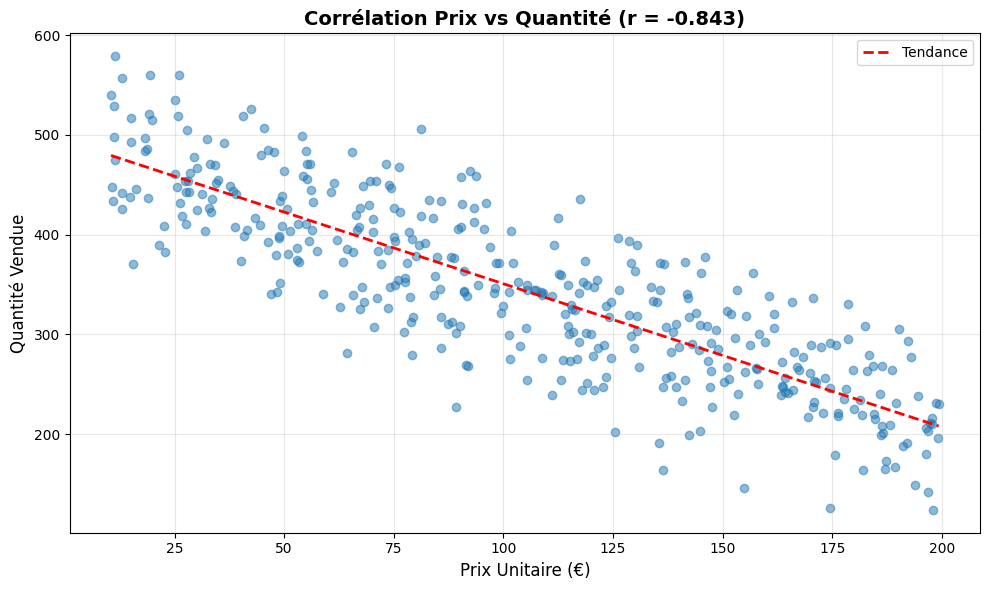

In [13]:
corr_prix_quantite = df_retail['prix_unitaire'].corr(df_retail['quantite_vendue'])

# Création du scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_retail['prix_unitaire'], df_retail['quantite_vendue'], alpha=0.5)
plt.xlabel('Prix Unitaire (€)', fontsize=12)
plt.ylabel('Quantité Vendue', fontsize=12)
plt.title(f'Corrélation Prix vs Quantité (r = {corr_prix_quantite:.3f})', fontsize=14, fontweight='bold')

# Ajout d'une ligne de tendance
z = np.polyfit(df_retail['prix_unitaire'], df_retail['quantite_vendue'], 1)
p = np.poly1d(z)
plt.plot(df_retail['prix_unitaire'].sort_values(), 
         p(df_retail['prix_unitaire'].sort_values()), 
         "r--", linewidth=2, label='Tendance')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ACP

#### Préparation des données pour l'ACP

In [ ]:
# pip install scikit-learn
from sklearn.preprocessing import StandardScaler

# Standardisation (normalisation) des données
# Objectif : moyenne = 0, écart-type = 1 pour chaque variable
# Avec standardisation : Toutes les variables ont la même échelle

# Création du scaler
scaler = StandardScaler()

# Applications aux données
df_normalise = pd.DataFrame(
    scaler.fit_transform(df_clients),
    columns=df_clients.columns
)

print("\nAvant normalisation")
print(df_clients.describe().loc[['mean', 'std']])

print("\Après normalisation")
print(df_normalise.describe().loc[['mean', 'std']])


Avant normalisation
            age  revenu_annuel  temps_site_min  montant_achats_euros  \
mean  35.350000   39336.992000       45.905800             595.89964   
std   11.130646   11006.612521       11.806136             222.46849   

      nb_visites_mois  taux_conversion  score_satisfaction  
mean        13.732000         0.108296            3.759000  
std          4.474844         0.023324            0.520347  
\Après normalisation
               age  revenu_annuel  temps_site_min  montant_achats_euros  \
mean -1.154632e-16   1.421085e-16   -5.400125e-16          1.136868e-16   
std   1.001002e+00   1.001002e+00    1.001002e+00          1.001002e+00   

      nb_visites_mois  taux_conversion  score_satisfaction  
mean     1.625367e-16     4.511946e-16        1.243450e-16  
std      1.001002e+00     1.001002e+00        1.001002e+00  


### Application de l'ACP avec Scikit-learn

In [15]:
from sklearn.decomposition import PCA

# Création et application de l'ACP
# On commence par créer toutes les composantes possibles

pca = PCA() # Par défaut : toutes les composantes
composantes = pca.fit_transform(df_normalise)

print(f"Nombre de variables originales : {df_normalise.shape}")
print(f"Nombre de composantes principales : {composantes.shape[1]}")

Nombre de variables originales : (500, 7)
Nombre de composantes principales : 7


## Interprétation : variance expliquée

La **variance expliquée** indique combien de % chaque composante capture.

In [16]:
variance_expliquee = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)

df_variance = pd.DataFrame({
    "Composante": [f"PC{i+1}" for i in range(len(variance_expliquee))],
    "Variance expliquée (%)": (variance_expliquee *100).round(2),
    "Variance cumulée (%)": (variance_cumulee *100).round(2),
})

df_variance

,Composante,Variance expliquée (%),Variance cumulée (%)
0,PC1,43.44,43.44
1,PC2,22.56,66.00
2,PC3,14.15,80.16
3,PC4,8.89,89.04
4,PC5,5.32,94.37
5,PC6,2.95,97.32
6,PC7,2.68,100.00


#### Interprétation

- **PC1** capture 43.44 % de la variance totale
- **PC1 + PC2** capturent 66% de ma variance totale
- **PC1 + PC2 + PC3** Capturent 80.16% de la variance total

#### visualisation

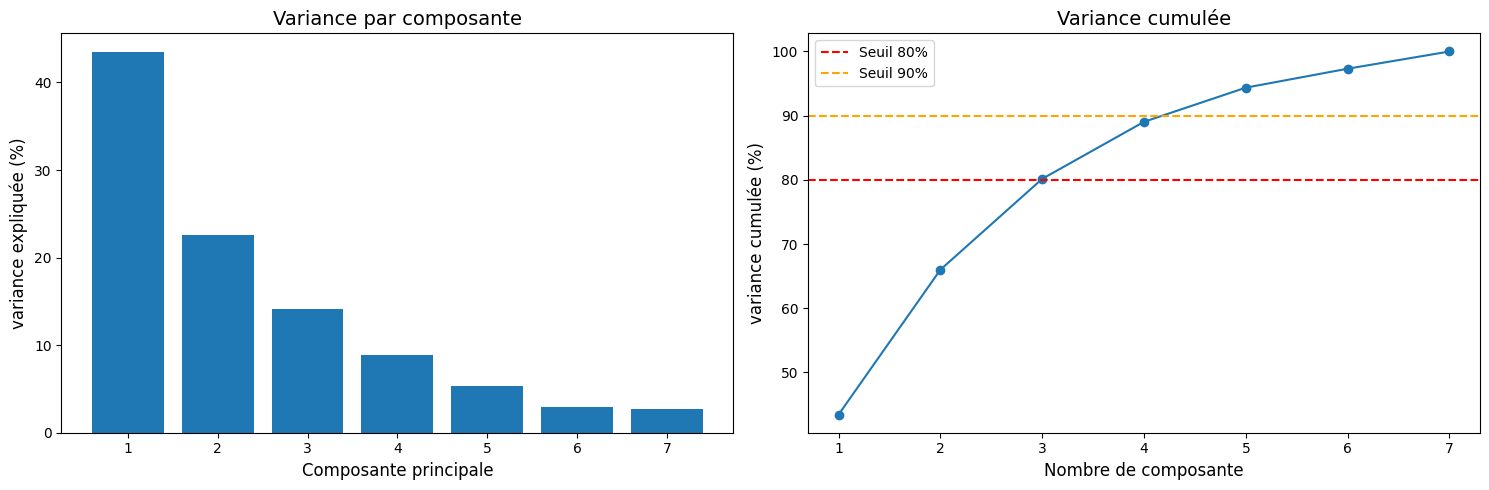

In [17]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

# Graphique 1
axes[0].bar(range(1, len(variance_expliquee) + 1), variance_expliquee * 100)
axes[0].set_xlabel("Composante principale", fontsize=12)
axes[0].set_ylabel("variance expliquée (%)", fontsize=12)
axes[0].set_title("Variance par composante", fontsize=14)

# Graphique 2
axes[1].plot(range(1, len(variance_cumulee) + 1), variance_cumulee * 100, marker='o')
axes[1].axhline(y=80, color="r", linestyle="--", label="Seuil 80%")
axes[1].axhline(y=90, color="orange", linestyle="--", label="Seuil 90%")
axes[1].set_xlabel("Nombre de composante", fontsize=12)
axes[1].set_ylabel("variance cumulée (%)", fontsize=12)
axes[1].set_title("Variance cumulée", fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

#### règle pratique

- On garde généralement les ocmposantes qui expliquent 80-90% de la variance
- Ici, on pourait passer de 7 variables à 3 composantes

## Les loadings : Contribution des variables

les **loadings** montrent comment chaque variable originale contribue à chaque composante principale.

In [18]:
# Extraction des loadings
loadings = pca.components_

df_loadings = pd.DataFrame(
    loadings[:3].T, # Transposée pour avoir les variables en lignes
    columns=["PC1", "PC2", "PC3"],
    index=df_clients.columns
)

df_loadings

,PC1,PC2,PC3
age,0.485681,0.152349,-0.081912
revenu_annuel,0.454362,0.377776,-0.038710
temps_site_min,-0.441974,0.398528,0.037099
montant_achats_euros,0.413590,0.413926,-0.013270
nb_visites_mois,-0.397478,0.390180,0.088984
taux_conversion,-0.157549,0.588061,-0.156146
score_satisfaction,0.091980,0.076542,0.978744


#### Comment interpréter

- Valeur proche de +1 ou -1 : forte contribution
- Valeur proche de 0: faible contribution
- Signe + ou - : la direction de la relation

#### visualisation

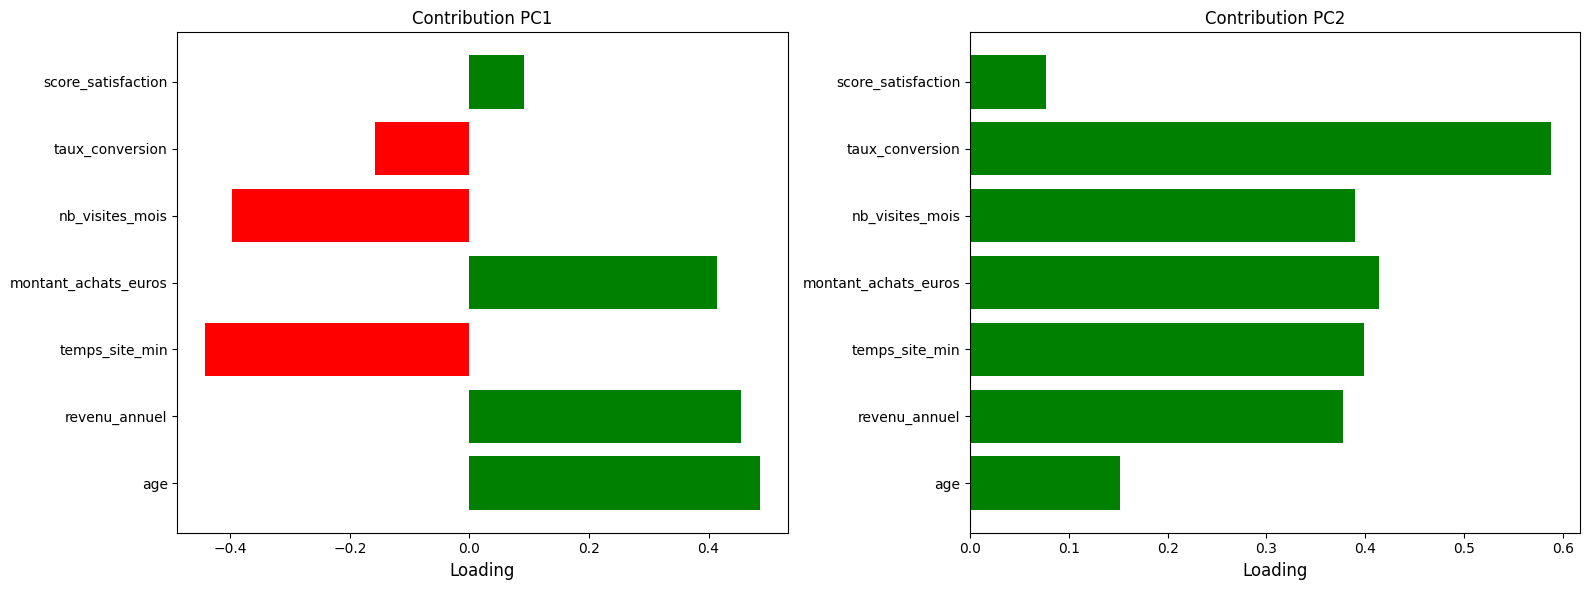

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# PC1
colors_pc1 = ["red" if x < 0 else "green" for x in df_loadings["PC1"]]
axes[0].barh(df_loadings.index, df_loadings["PC1"], color=colors_pc1)
axes[0].set_xlabel("Loading", fontsize=12)
axes[0].set_title("Contribution PC1")

# PC2
colors_pc2 = ["red" if x < 0 else "green" for x in df_loadings["PC2"]]
axes[1].barh(df_loadings.index, df_loadings["PC2"], color=colors_pc2)
axes[1].set_xlabel("Loading", fontsize=12)
axes[1].set_title("Contribution PC2")

plt.tight_layout()
plt.show()

# Visualisation en 2D

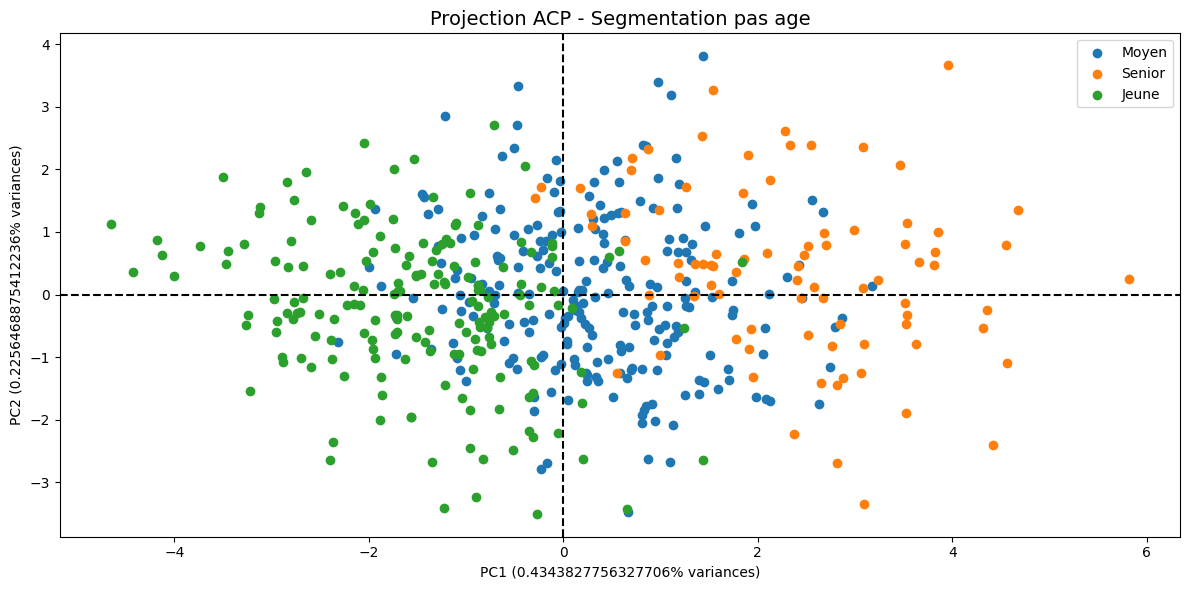

In [24]:
df_pca = pd.DataFrame(
    composantes[:,:2],
    columns=["PC1", "PC2"]
)

df_pca["Segment_age"] = pd.cut(df_clients["age"], bins=[0, 30, 45, 100], labels=["Jeune", "Moyen", "Senior"])

plt.figure(figsize=(12, 6))

plt.subplot(1,1,1)

for segment in df_pca["Segment_age"].unique():
    mask = df_pca["Segment_age"] == segment
    plt.scatter(df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"], label=segment)

plt.xlabel(f"PC1 ({variance_expliquee[0]}% variances)")
plt.ylabel(f"PC2 ({variance_expliquee[1]}% variances)")
plt.title("Projection ACP - Segmentation pas age", fontsize=14)
plt.axhline(y=0, color="k", linestyle="--")
plt.axvline(x=0, color="k", linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

### Biplot : variables et observations ensemble

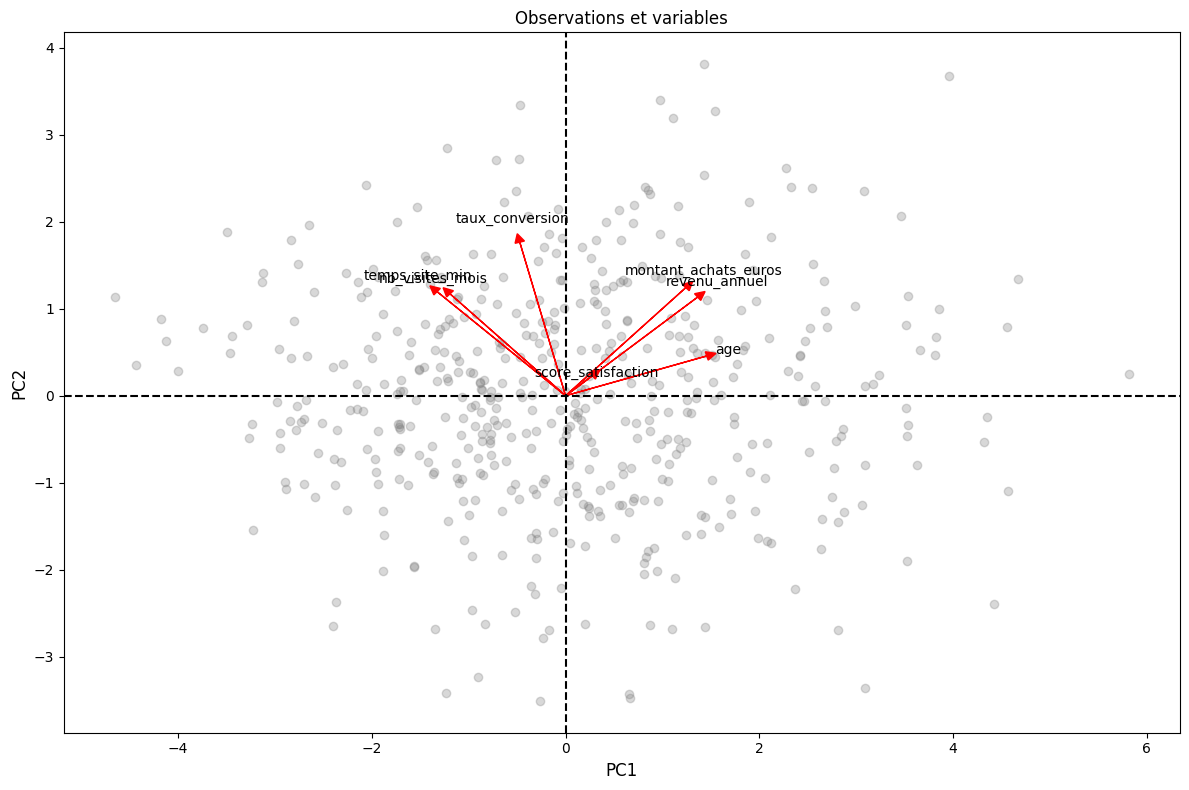

In [29]:
plt.figure(figsize=(12, 8))

plt.scatter(composantes[:, 0], composantes[:, 1], alpha=0.3, c="gray")

scale_factor = 3 # pour rendre la flèche visible
for i, label in enumerate(df_clients.columns):
    plt.arrow(0,0,
              loadings[0, i] * scale_factor,
              loadings[1, i] * scale_factor,
              fc="red", ec="red", head_length=0.1, head_width=0.1)
    plt.text(loadings[0, i] * scale_factor * 1.15,
              loadings[1, i] * scale_factor * 1.15, label, ha="center", va="center")
    
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title("Observations et variables")
plt.axhline(y=0, color="k", linestyle="--")
plt.axvline(x=0, color="k", linestyle="--")
plt.tight_layout()
plt.show()

#### Interprétation

- Les flèches rouge = variables originales
- Direction de la flèche = Contribution à PC1 et PC2
- Longueur de la flèche = importance de la variable

## Réduction de la dimensionnalité


In [31]:
n_composantes = 3

# Nouvelle ACP avec seulement les 3 composantes
pca_reduit = PCA(n_components=n_composantes)
df_reduit = pca_reduit.fit_transform(df_normalise)

df_reduit = pd.DataFrame(df_reduit, columns=[f"PC{1+i}" for i in range(n_composantes)])

df_reduit.head()

,PC1,PC2,PC3
0,0.421747,1.995889,-1.838078
1,-0.170023,1.856552,-0.843370
2,0.246702,-1.382235,-0.496136
3,3.508887,-0.142455,1.745980
4,-0.561164,-1.088040,0.581672


#### Cas d'usage

- Ces 3 composantes peuvent maintenant être utilisée dans un modèle de ML
- Plus rapide à calculer, moins de risque de sur-apprentissage

## EXERCICE 2 : ACP Complète
 
**Objectif** : Réaliser une ACP complète sur un nouveau dataset
 
**Contexte** : Vous êtes data analyst dans une entreprise de télécommunications. Vous devez analyser les profils de clients pour identifier des segments.
 
**Consignes** :
 
1. Normalisez les données
2. Appliquez une ACP
3. Analysez la variance expliquée et créez un scree plot
4. Déterminez combien de composantes garder (objectif : 85% de variance)
5. Interprétez les 2 premières composantes (loadings)
6. Créez une visualisation PC1 vs PC2

In [32]:
np.random.seed(456)
n_clients_telecom = 600
 
anciennete = np.random.uniform(1, 120, n_clients_telecom)  # mois
facture_mensuelle = 30 + anciennete * 0.3 + np.random.normal(0, 15, n_clients_telecom)
facture_mensuelle = np.clip(facture_mensuelle, 20, 150)
 
data_usage = 5 + (facture_mensuelle / 10) + np.random.normal(0, 3, n_clients_telecom)
data_usage = np.clip(data_usage, 1, 50)
 
nb_appels_support = 10 - (anciennete / 20) + np.random.poisson(2, n_clients_telecom)
nb_appels_support = np.clip(nb_appels_support, 0, 20)
 
score_satisfaction = 3.5 + (anciennete / 100) - (nb_appels_support / 20) + np.random.normal(0, 0.5, n_clients_telecom)
score_satisfaction = np.clip(score_satisfaction, 1, 5)
 
nb_services = np.random.poisson(3, n_clients_telecom)
nb_services = np.clip(nb_services, 1, 7)
 
taux_paiement_retard = 0.1 - (score_satisfaction / 100) + np.random.normal(0, 0.05, n_clients_telecom)
taux_paiement_retard = np.clip(taux_paiement_retard, 0, 0.5)
 
df_telecom = pd.DataFrame({
    'anciennete_mois': anciennete.round(0),
    'facture_mensuelle': facture_mensuelle.round(2),
    'data_usage_gb': data_usage.round(1),
    'nb_appels_support': nb_appels_support,
    'score_satisfaction': score_satisfaction.round(1),
    'nb_services_actifs': nb_services,
    'taux_paiement_retard': taux_paiement_retard.round(3)
})
 
print("Dataset Télécommunications chargé !")
print(f"Dimensions : {df_telecom.shape}")
print("\nAperçu :")
df_telecom.head()

Dataset Télécommunications chargé !
Dimensions : (600, 7)

Aperçu :


,anciennete_mois,facture_mensuelle,data_usage_gb,nb_appels_support,score_satisfaction,nb_services_actifs,taux_paiement_retard
0,31.0,82.20,16.2,9.469902,3.4,2,0.084
1,20.0,36.62,11.5,9.979753,3.1,4,0.121
2,94.0,53.87,11.9,7.287323,4.1,1,0.070
3,97.0,33.57,6.4,7.139286,2.9,2,0.187
4,75.0,46.62,11.2,7.227511,4.9,3,0.074


In [33]:
# 1. Normalisation des données
# Création du scaler
scaler_telecom = StandardScaler()
 
# Application de la normalisation
df_telecom_normalise = pd.DataFrame(
    scaler_telecom.fit_transform(df_telecom),
    columns=df_telecom.columns
)
 
print("Normalisation effectuée :")
print("\nAVANT normalisation :")
print(df_telecom.describe().loc[['mean', 'std']].round(2))
 
print("\nAPRÈS normalisation :")
print(df_telecom_normalise.describe().loc[['mean', 'std']].round(2))

Normalisation effectuée :

AVANT normalisation :
      anciennete_mois  facture_mensuelle  data_usage_gb  nb_appels_support  \
mean            60.76              48.38           9.91               8.93   
std             34.15              16.98           3.49               2.08   

      score_satisfaction  nb_services_actifs  taux_paiement_retard  
mean                3.65                3.06                  0.07  
std                 0.65                1.61                  0.05  

APRÈS normalisation :
      anciennete_mois  facture_mensuelle  data_usage_gb  nb_appels_support  \
mean              0.0                0.0            0.0               -0.0   
std               1.0                1.0            1.0                1.0   

      score_satisfaction  nb_services_actifs  taux_paiement_retard  
mean                -0.0                -0.0                  -0.0  
std                  1.0                 1.0                   1.0  


In [34]:
# 2. Application de l'ACP
# Création de l'ACP avec toutes les composantes
pca_telecom = PCA()
composantes_telecom = pca_telecom.fit_transform(df_telecom_normalise)
 
print(f"Nombre de variables originales : {df_telecom_normalise.shape[1]}")
print(f"Nombre de composantes principales créées : {composantes_telecom.shape[1]}")

Nombre de variables originales : 7
Nombre de composantes principales créées : 7


In [35]:
# 3. Analyse de la variance expliquée et scree plot
# Calcul de la variance expliquée par chaque composante
variance_exp_telecom = pca_telecom.explained_variance_ratio_
variance_cum_telecom = np.cumsum(variance_exp_telecom)
 
# Création d'un tableau récapitulatif
df_variance_telecom = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(variance_exp_telecom))],
    'Variance expliquée (%)': (variance_exp_telecom * 100).round(2),
    'Variance cumulée (%)': (variance_cum_telecom * 100).round(2)
})
 
print("Variance expliquée par composante :")
df_variance_telecom

Variance expliquée par composante :


,Composante,Variance expliquée (%),Variance cumulée (%)
0,PC1,41.64,41.64
1,PC2,15.65,57.29
2,PC3,14.49,71.78
3,PC4,12.72,84.50
4,PC5,6.86,91.36
5,PC6,5.44,96.80
6,PC7,3.20,100.00


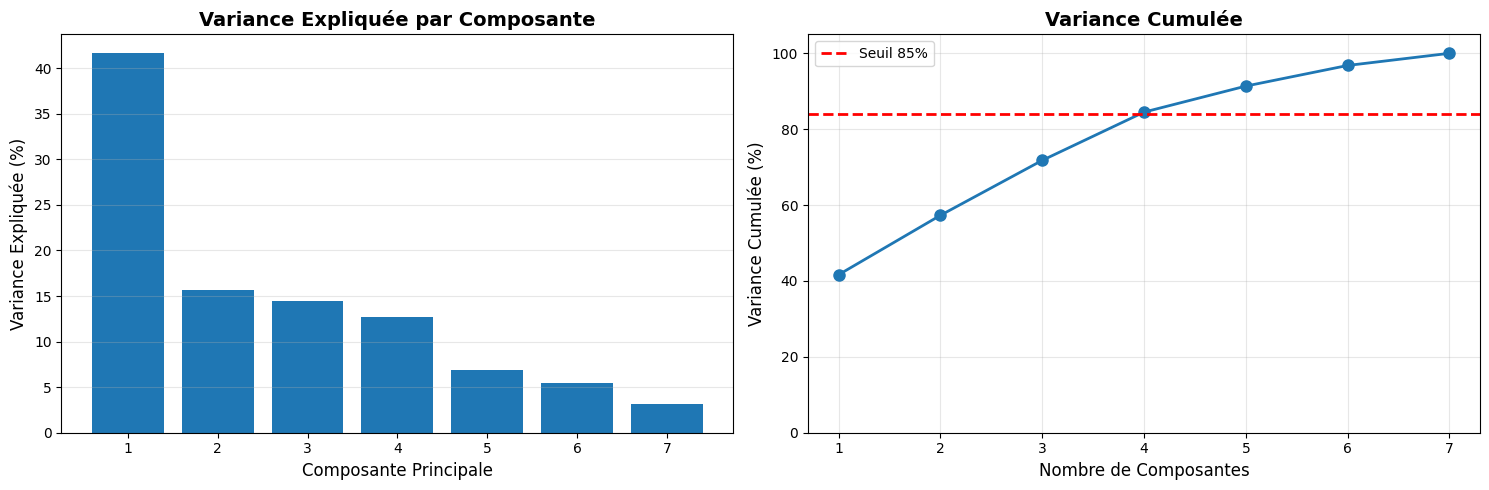

In [36]:
# Création du scree plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Graphique 1 : Variance par composante
axes[0].bar(range(1, len(variance_exp_telecom) + 1), variance_exp_telecom * 100)
axes[0].set_xlabel('Composante Principale', fontsize=12)
axes[0].set_ylabel('Variance Expliquée (%)', fontsize=12)
axes[0].set_title('Variance Expliquée par Composante', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
 
# Graphique 2 : Variance cumulée avec seuil à 85%
axes[1].plot(range(1, len(variance_cum_telecom) + 1), variance_cum_telecom * 100,
             marker='o', linewidth=2, markersize=8)
axes[1].axhline(y=84, color='r', linestyle='--', label='Seuil 85%', linewidth=2)
axes[1].set_xlabel('Nombre de Composantes', fontsize=12)
axes[1].set_ylabel('Variance Cumulée (%)', fontsize=12)
axes[1].set_title('Variance Cumulée', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])
 
plt.tight_layout()
plt.show()

In [ ]:
# 4. Détermination du nombre de composantes à garder (objectif : 84%)
# Trouver le nombre de composantes nécessaires pour atteindre 84% de variance
n_comp_84 = np.argmax(variance_cum_telecom >= 0.84) + 1
 
print(f"Nombre de composantes nécessaires pour 85% de variance : {n_comp_84}")
print(f"Variance exacte conservée : {variance_cum_telecom[n_comp_84-1]*100:.2f}%")
print(f"\nRéduction de dimensionnalité :")
print(f"  • AVANT : {df_telecom.shape[1]} variables")
print(f"  • APRÈS : {n_comp_84} composantes")
print(f"  • Réduction : {(1 - n_comp_84/df_telecom.shape[1])*100:.1f}%")

Nombre de composantes nécessaires pour 85% de variance : 4
Variance exacte conservée : 84.50%

Réduction de dimensionnalité :
  • AVANT : 7 variables
  • APRÈS : 4 composantes
  • Réduction : 42.9%


In [38]:
# 5. Interprétation des 2 premières composantes (loadings)
# Extraction des loadings
loadings_telecom = pca_telecom.components_
 
# Création d'un DataFrame pour les 2 premières composantes
df_loadings_telecom = pd.DataFrame(
    loadings_telecom[:2].T,  # Transposée pour avoir variables en lignes
    columns=['PC1', 'PC2'],
    index=df_telecom.columns
)
 
print("Loadings (contributions des variables) :")
df_loadings_telecom.round(3)

Loadings (contributions des variables) :


,PC1,PC2
anciennete_mois,0.519,-0.101
facture_mensuelle,0.452,0.313
data_usage_gb,0.320,0.568
nb_appels_support,-0.476,0.191
score_satisfaction,0.436,-0.288
nb_services_actifs,-0.005,-0.189
taux_paiement_retard,-0.085,0.644


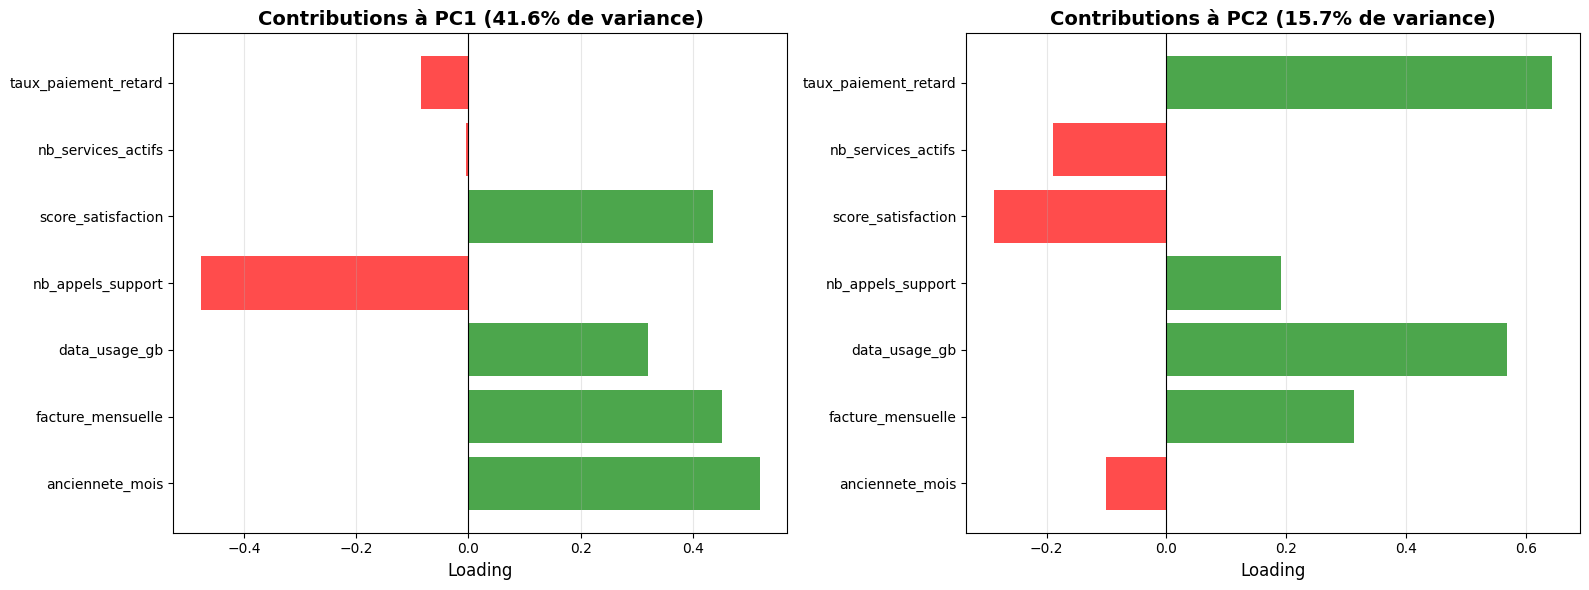

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# PC1
colors_pc1 = ['red' if x < 0 else 'green' for x in df_loadings_telecom['PC1']]
axes[0].barh(df_loadings_telecom.index, df_loadings_telecom['PC1'],
             color=colors_pc1, alpha=0.7)
axes[0].set_xlabel('Loading', fontsize=12)
axes[0].set_title(f'Contributions à PC1 ({variance_exp_telecom[0]*100:.1f}% de variance)',
                   fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)
 
# PC2
colors_pc2 = ['red' if x < 0 else 'green' for x in df_loadings_telecom['PC2']]
axes[1].barh(df_loadings_telecom.index, df_loadings_telecom['PC2'],
             color=colors_pc2, alpha=0.7)
axes[1].set_xlabel('Loading', fontsize=12)
axes[1].set_title(f'Contributions à PC2 ({variance_exp_telecom[1]*100:.1f}% de variance)',
                   fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)
 
plt.tight_layout()
plt.show()

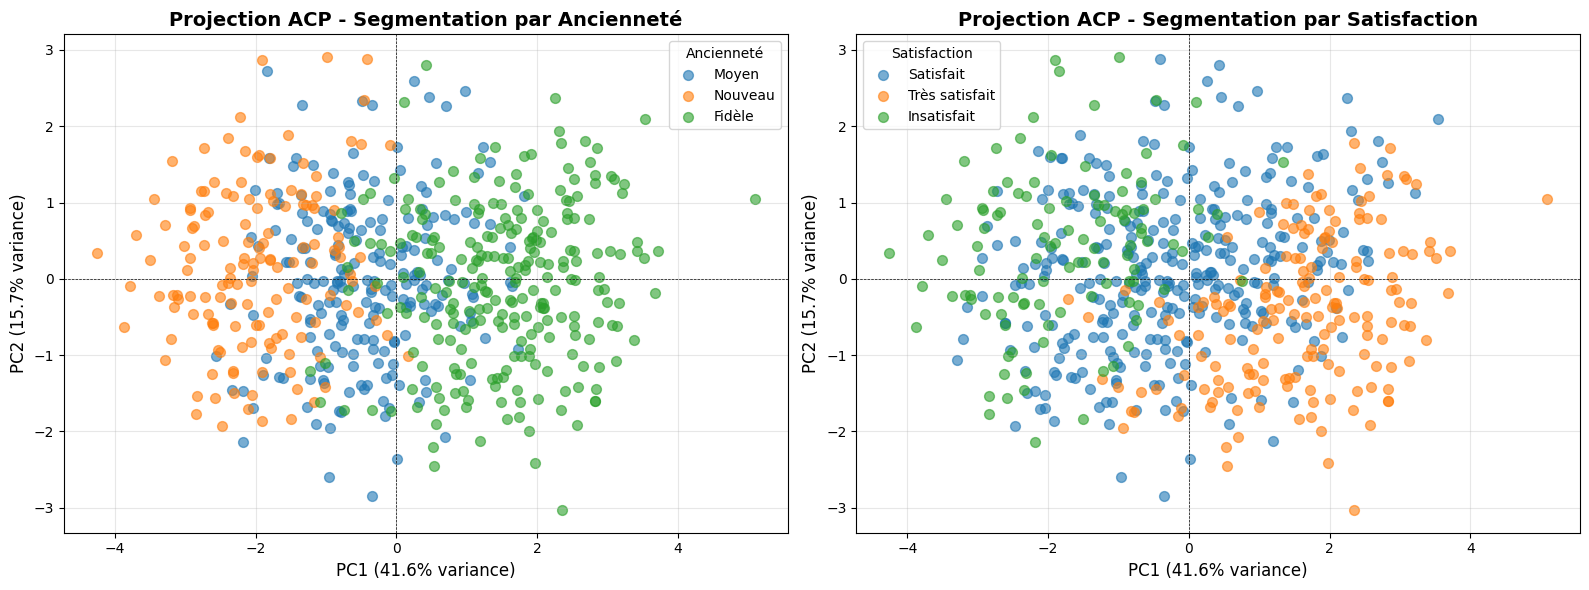

In [40]:
# 6. Visualisation PC1 vs PC2
# Création d'un DataFrame avec les composantes
df_pca_telecom = pd.DataFrame(
    composantes_telecom[:, :2],
    columns=['PC1', 'PC2']
)
 
# Ajout de segments pour la coloration
# Segmentation par ancienneté
df_pca_telecom['segment_anciennete'] = pd.cut(
    df_telecom['anciennete_mois'],
    bins=[0, 30, 70, 150],
    labels=['Nouveau', 'Moyen', 'Fidèle']
)
 
# Segmentation par satisfaction
df_pca_telecom['segment_satisfaction'] = pd.cut(
    df_telecom['score_satisfaction'],
    bins=[0, 3, 4, 5],
    labels=['Insatisfait', 'Satisfait', 'Très satisfait']
)
 
# Création des visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Graphique 1 : Coloré par ancienneté
for segment in df_pca_telecom['segment_anciennete'].unique():
    mask = df_pca_telecom['segment_anciennete'] == segment
    axes[0].scatter(df_pca_telecom.loc[mask, 'PC1'],
                    df_pca_telecom.loc[mask, 'PC2'],
                    label=segment, alpha=0.6, s=50)
 
axes[0].set_xlabel(f'PC1 ({variance_exp_telecom[0]*100:.1f}% variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({variance_exp_telecom[1]*100:.1f}% variance)', fontsize=12)
axes[0].set_title('Projection ACP - Segmentation par Ancienneté', fontsize=14, fontweight='bold')
axes[0].legend(title='Ancienneté')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='--', linewidth=0.5)
 
# Graphique 2 : Coloré par satisfaction
for segment in df_pca_telecom['segment_satisfaction'].unique():
    mask = df_pca_telecom['segment_satisfaction'] == segment
    axes[1].scatter(df_pca_telecom.loc[mask, 'PC1'],
                    df_pca_telecom.loc[mask, 'PC2'],
                    label=segment, alpha=0.6, s=50)
 
axes[1].set_xlabel(f'PC1 ({variance_exp_telecom[0]*100:.1f}% variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({variance_exp_telecom[1]*100:.1f}% variance)', fontsize=12)
axes[1].set_title('Projection ACP - Segmentation par Satisfaction', fontsize=14, fontweight='bold')
axes[1].legend(title='Satisfaction')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[1].axvline(x=0, color='k', linestyle='--', linewidth=0.5)
 
plt.tight_layout()
plt.show()